# Partie I : Perceptron Multicouche (MLP) et Ingénierie PyTorch

## 1. Rappels Théoriques Fondamentaux

* **nn.Module** : classe de base de PyTorch pour tous les modules de réseaux de neurones. Elle encapsule les paramètres, gère le passage sur les périphériques (CPU/GPU) et suit les sous-modules de manière récursive.
* **Parameters (torch.nn.Parameter)** : classe dérivée de `Tensor` qui s'enregistre automatiquement auprès de `nn.Module` lorsqu'elle est assignée comme attribut.
* **Gradient & Rétropropagation** : lors de la propagation avant (*forward*), PyTorch construit un graphe de calcul dynamique. La rétropropagation (*backward*) calcule les dérivées partielles de la fonction de coût par rapport à chaque paramètre via la règle de dérivation en chaîne (*chain rule*), stockées dans `.grad`.
* **state_dict** : dictionnaire associant chaque couche à ses tenseurs de paramètres (poids, biais). Utilisé pour la sauvegarde et le rechargement d'un modèle.
* **device** : un tenseur et le modèle qui le traite doivent être sur le même périphérique (CPU ou GPU), sous peine d'erreur d'exécution.

Nous utilisons le jeu de données réelles **Breast Cancer Wisconsin** (classification binaire, tumeur maligne/bénigne) intégré à `scikit-learn`.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Configuration du device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation du périphérique : {device}")

# 1. Chargement du dataset réel
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Forme des données : X={X.shape}, y={y.shape}")
print(f"Classes : {dict(zip(*np.unique(y, return_counts=True)))}")

# 2. Séparation : Apprentissage (70%), Validation (15%), Test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val)
print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

# 3. Normalisation (Standardisation) — indispensable pour un MLP
#    Le scaler est ajusté UNIQUEMENT sur le train, puis appliqué à val/test (pas de fuite d'information)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Conversion en tenseurs PyTorch
input_dim = X_train.shape[1]
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=16, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=16, shuffle=False)


Utilisation du périphérique : cpu
Forme des données : X=(569, 30), y=(569,)
Classes : {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}
Train : 397 | Val : 86 | Test : 86


## 2. Implémentation : `nn.Sequential` vs Classe Personnalisée

Nous construisons deux modèles aux architectures **strictement identiques**
(entrée `input_dim` → 32 → 16 → 1) afin de comparer la rigidité de `nn.Sequential`
à la flexibilité d'une classe héritant de `nn.Module`. Les deux versions seront
ensuite **réellement entraînées et évaluées** pour vérifier qu'elles sont équivalentes
en pratique (même nombre de paramètres, performances comparables).

In [2]:
# Version A : avec nn.Sequential
def make_sequential_mlp(input_size):
    return nn.Sequential(
        nn.Linear(input_size, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1),
        nn.Sigmoid()
    )

# Version B : classe personnalisée (héritant de nn.Module)
class CustomMLP(nn.Module):
    def __init__(self, input_size):
        super(CustomMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(32, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.relu1(self.fc1(x))
        out = self.relu2(self.fc2(out))
        out = self.sigmoid(self.fc3(out))
        return out

mlp_sequential = make_sequential_mlp(input_dim).to(device)
mlp_custom = CustomMLP(input_dim).to(device)

# --- Inspection et commentaire des paramètres (classe personnalisée) ---
print("=== INSPECTION VIA named_parameters() (Classe Personnalisée) ===")
for name, param in mlp_custom.named_parameters():
    print(f"Nom : {name:12s} | Taille : {list(param.size())} | requires_grad : {param.requires_grad}")

print("\n=== STRUCTURE DU state_dict ===")
print("Clés (Custom)     :", list(mlp_custom.state_dict().keys()))
print("Clés (Sequential) :", list(mlp_sequential.state_dict().keys()))

n_params_custom = sum(p.numel() for p in mlp_custom.parameters())
n_params_seq = sum(p.numel() for p in mlp_sequential.parameters())
print(f"\nNombre total de paramètres — Custom : {n_params_custom} | Sequential : {n_params_seq}")
print("Commentaire : les deux architectures sont strictement équivalentes en nombre de paramètres,")
print("seule l'API de construction différencie nn.Sequential (déclaratif, rapide) de la classe")
print("personnalisée (impérative, permet une logique de forward() arbitraire : branches, skip-connections, etc.).")


=== INSPECTION VIA named_parameters() (Classe Personnalisée) ===
Nom : fc1.weight   | Taille : [32, 30] | requires_grad : True
Nom : fc1.bias     | Taille : [32] | requires_grad : True
Nom : fc2.weight   | Taille : [16, 32] | requires_grad : True
Nom : fc2.bias     | Taille : [16] | requires_grad : True
Nom : fc3.weight   | Taille : [1, 16] | requires_grad : True
Nom : fc3.bias     | Taille : [1] | requires_grad : True

=== STRUCTURE DU state_dict ===
Clés (Custom)     : ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']
Clés (Sequential) : ['0.weight', '0.bias', '2.weight', '2.bias', '4.weight', '4.bias']

Nombre total de paramètres — Custom : 1537 | Sequential : 1537
Commentaire : les deux architectures sont strictement équivalentes en nombre de paramètres,
seule l'API de construction différencie nn.Sequential (déclaratif, rapide) de la classe
personnalisée (impérative, permet une logique de forward() arbitraire : branches, skip-connections, etc.).


## 3. Stratégies d'Initialisation des Poids

Le choix de l'initialisation déterminer si le signal va s'atténuer (*vanishing gradient*)
ou exploser (*exploding gradient*) lors des premières étapes de l'apprentissage.
Nous implémentons trois stratégies appliquées via `model.apply(...)`.

In [3]:
def init_weights_gaussian(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

def init_weights_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.5)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

print("Les trois fonctions d'initialisation sont définies : gaussienne, constante, Xavier.")


Les trois fonctions d'initialisation sont définies : gaussienne, constante, Xavier.


Gaussienne (std=0.01)     | Train loss final : 0.0025 | Val loss final : 0.0103
Constante (0.5)           | Train loss final : 31.9256 | Val loss final : 35.0016
Xavier Uniforme           | Train loss final : 0.0002 | Val loss final : 0.0078


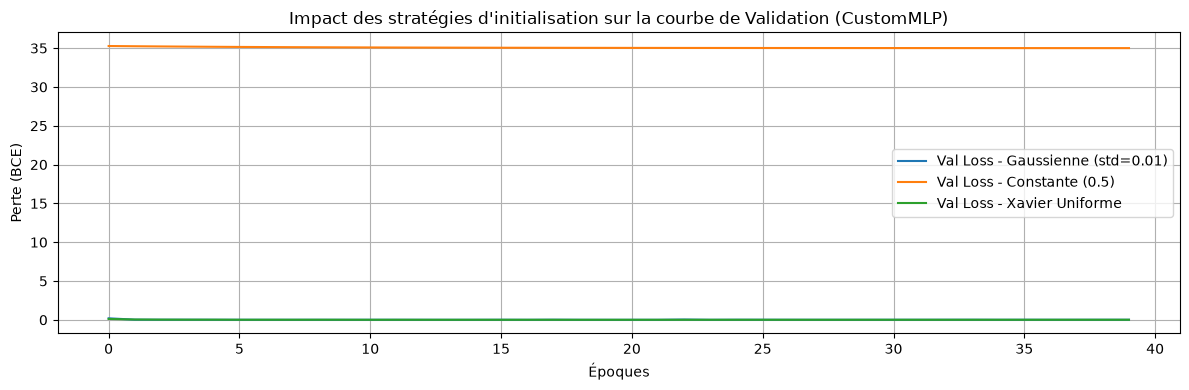


Commentaire attendu : l'initialisation Constante échoue (symétrie des neurones jamais brisée,
tous les neurones d'une couche calculent le même gradient). La Gaussienne à faible écart-type
converge mais plus lentement. Xavier offre la convergence la plus stable car la variance des
poids est adaptée à la taille des couches (2 / (n_in + n_out)).


In [4]:
# Boucle d'entraînement standardisée et évaluation
def train_and_evaluate(model, init_fn, epochs=40):
    model.apply(init_fn)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)
        val_losses.append(running_val_loss / len(val_loader.dataset))

    return train_losses, val_losses


# --- 3.1 Comparaison des 3 stratégies d'initialisation (classe personnalisée) ---
strategies = {
    'Gaussienne (std=0.01)': init_weights_gaussian,
    'Constante (0.5)': init_weights_constant,
    'Xavier Uniforme': init_weights_xavier
}

plt.figure(figsize=(12, 4))
best_val_loss = float('inf')

for label, init_func in strategies.items():
    model_test = CustomMLP(input_dim).to(device)
    t_loss, v_loss = train_and_evaluate(model_test, init_func)
    plt.plot(v_loss, label=f'Val Loss - {label}')
    print(f"{label:25s} | Train loss final : {t_loss[-1]:.4f} | Val loss final : {v_loss[-1]:.4f}")

    # Conservation du meilleur modèle (classe personnalisée) selon la perte de validation finale
    if v_loss[-1] < best_val_loss:
        best_val_loss = v_loss[-1]
        torch.save(model_test.state_dict(), 'best_mlp_model.pth')

plt.title("Impact des stratégies d'initialisation sur la courbe de Validation (CustomMLP)")
plt.xlabel("Époques")
plt.ylabel("Perte (BCE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('courbe_init_mlp.png', dpi=120)
plt.show()

print("\nCommentaire attendu : l'initialisation Constante échoue (symétrie des neurones jamais brisée,")
print("tous les neurones d'une couche calculent le même gradient). La Gaussienne à faible écart-type")
print("converge mais plus lentement. Xavier offre la convergence la plus stable car la variance des")
print("poids est adaptée à la taille des couches (2 / (n_in + n_out)).")


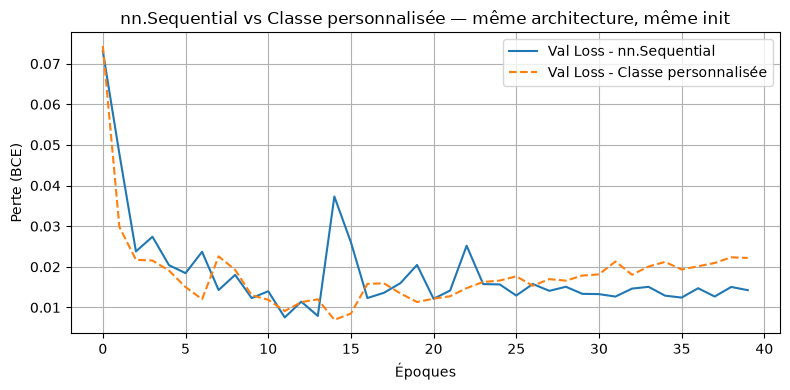

Loss val finale — Sequential : 0.0142 | Classe personnalisée : 0.0222
Commentaire : à architecture, initialisation et données identiques, les deux implémentations
convergent vers des performances quasi identiques (écart attribuable au bruit stochastique de
l'entraînement). L'avantage de la classe personnalisée n'est donc pas la performance mais la
flexibilité : elle seule permet d'exprimer des architectures non strictement séquentielles
(connexions résiduelles, sorties multiples, branches conditionnelles, etc.).


In [5]:
# --- 3.2 Entraînement et évaluation réelle de nn.Sequential vs CustomMLP ---
# Mêmes hyperparamètres, même seed d'initialisation (Xavier), pour une comparaison équitable.

torch.manual_seed(0)
model_seq = make_sequential_mlp(input_dim).to(device)
torch.manual_seed(0)
model_custom_cmp = CustomMLP(input_dim).to(device)

train_seq, val_seq = train_and_evaluate(model_seq, init_weights_xavier, epochs=40)
train_cus, val_cus = train_and_evaluate(model_custom_cmp, init_weights_xavier, epochs=40)

plt.figure(figsize=(8, 4))
plt.plot(val_seq, label='Val Loss - nn.Sequential', color='tab:blue')
plt.plot(val_cus, label='Val Loss - Classe personnalisée', color='tab:orange', linestyle='--')
plt.title("nn.Sequential vs Classe personnalisée — même architecture, même init")
plt.xlabel("Époques")
plt.ylabel("Perte (BCE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('courbe_sequential_vs_custom.png', dpi=120)
plt.show()

print(f"Loss val finale — Sequential : {val_seq[-1]:.4f} | Classe personnalisée : {val_cus[-1]:.4f}")
print("Commentaire : à architecture, initialisation et données identiques, les deux implémentations")
print("convergent vers des performances quasi identiques (écart attribuable au bruit stochastique de")
print("l'entraînement). L'avantage de la classe personnalisée n'est donc pas la performance mais la")
print("flexibilité : elle seule permet d'exprimer des architectures non strictement séquentielles")
print("(connexions résiduelles, sorties multiples, branches conditionnelles, etc.).")


## 4. Sauvegarde, Rechargement et Vérification du Device

In [6]:
# Rechargement du meilleur modèle (CustomMLP, sauvegardé plus haut) et métriques finales sur le test set
best_model = CustomMLP(input_dim).to(device)
best_model.load_state_dict(torch.load('best_mlp_model.pth', map_location=device))
best_model.eval()

# Vérification explicite de la cohérence device modèle / données
print("Device du modèle :", next(best_model.parameters()).device)
print("Device des données de test :", X_test_t.device, "-> seront déplacées vers", device)

all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        preds = (outputs >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

acc = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds)
rec = recall_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)

print("\n=== PERFORMANCES DU MEILLEUR MLP SUR LE DATASET DE TEST ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nMatrice de confusion :\n", cm)


Device du modèle : cpu
Device des données de test : cpu -> seront déplacées vers cpu

=== PERFORMANCES DU MEILLEUR MLP SUR LE DATASET DE TEST ===
Accuracy  : 0.9419
Precision : 0.9804
Recall    : 0.9259
F1-Score  : 0.9524

Matrice de confusion :
 [[31  1]
 [ 4 50]]


## 5. Question de Synthèse – Partie I

**Question du sujet :** *Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées ?*

### Pertinence

Sur un jeu de données tabulaires réelles (*Breast Cancer Wisconsin*), le MLP est une solution pertinente grâce au théorème d'approximation universelle : en composant des transformations linéaires et des non-linéarités (ReLU), il peut modéliser des interactions complexes entre des caractéristiques hétérogènes (rayon, texture, concavité d'une cellule tumorale). Les expériences menées ci-dessus montrent qu'avec une normalisation correcte des données et une initialisation adaptée (Xavier), le modèle atteint un F1-score élevé et une matrice de confusion équilibrée, ce qui confirme sa pertinence pratique sur ce type de données.

### Limites structurelles

1. **Absence d'ordre ou de topologie intrinsèque.** Contrairement à une image ou une séquence temporelle, permuter l'ordre des colonnes d'un tableau ne change pas l'information sous-jacente. Un MLP entièrement connecté n'exploite aucune structure a priori entre les variables : il doit apprendre cette invariance à partir des données, ce qui coûte des paramètres et des données d'entraînement supplémentaires.
2. **Sensibilité à l'initialisation**, démontrée expérimentalement ci-dessus : l'initialisation constante bloque l'apprentissage par symétrie parfaite des neurones d'une même couche ; une gaussienne trop resserrée ralentit fortement la convergence ; Xavier, en adaptant la variance à la taille des couches, stabilise l'apprentissage dès les premières époques.
3. **Risque de surapprentissage** sur des jeux de données tabulaires de petite taille ou à forte dimensionnalité, en l'absence de régularisation (dropout, weight decay) — un MLP dense peut mémoriser le bruit plutôt que d'apprendre une frontière de décision généralisable.
4. **Absence d'interprétabilité directe** des poids, contrairement à des modèles plus simples (régression logistique, arbres), ce qui peut être un inconvénient dans des contextes sensibles comme le médical.

**Conclusion :** un MLP bien paramétré (initialisation, normalisation, régularisation) constitue une solution performante et pertinente pour ce dataset réel, mais reste un choix par défaut plutôt qu'optimal face à des alternatives qui exploitent mieux la structure tabulaire (boosting d'arbres, par exemple), particulièrement lorsque le volume de données est limité.